## Пример выполнения работы 2 - Работа с данными и EDA
**Используется набор данных "Титаник"**

In [1]:
# импорт библиотек
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt # библиотека для визуализации данных
import seaborn as sns # еще одна библиотека для продвинутой визуализации данных

### 1. Загрузка данных

In [107]:
data = pd.read_csv("Titanic_train1.csv") # считываем датасет по пассажирам Титаника

#### Проверка правильности считывания данных

In [6]:
# проверка считывания данных
data.tail() 

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


### 2. Предварительное знакомство с данными
**Краткая характеристика признаков:**
Целевой параметр - Survived. Параметр описывает исход катастрофы Титаника для конкретного пассажира.  
Имеет 2 значения: 0 - погиб, 1 - выжил.
1. PassengerId - номер пассажира в списке, служебный, в работе не используется.
2. Pclass - класс каюты, которым следовал пассажир.
3. Name - имя пассажира.
4. Sex - пол пассажира. 
5. Age - возраст пассажира. 
6. SibSp - супруги, братья, сестры на борту.
7. Parch - родители/дети на борту.
8. Ticket - номер билета, зависит от места покупки билета.
9. Fare - плата за билет. 
10. Cabin - номер каюты.
11. Embarked - порт посадки.  
**Проанализируем структуру данных**

In [8]:
data.info() # информация о структуре данных

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


### 3. Кодирование признаков
#### 3.1. Предварительный отбор признаков
Рассмотрим следующие признаки: 
1. Имя пассажира: сомнительно, что этот признак несет полезную информацию.  
2. Номер билета: для того, чтобы разобраться - что он значит, нужно отдельное исследование.  
3. Номер каюты: информация может быть очень полезной, но отсутствует почти у четверти пассажиров. Пытаться ее восстановить - слишком сложная задача.  
На данном этапе предлагается удалить эти признаки из датасета.  
*Отметим, что в соревнованиях есть успешные попытки использовать эти поля для восстановления данных (например, о номере каюты) и для конструирования признаков.*

In [10]:
data = data.drop(['Name','Ticket','Cabin'], axis = 1)
print(data.info(),'\n') # информация о структуре данных

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Sex          891 non-null    object 
 4   Age          714 non-null    float64
 5   SibSp        891 non-null    int64  
 6   Parch        891 non-null    int64  
 7   Fare         891 non-null    float64
 8   Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(2)
memory usage: 62.8+ KB
None 



В датасете осталось два нечисловых поля: Sex (пол) и Embarked (пункт посадки). Определим, какие значения они принимают.

In [12]:
print(data['Sex'].value_counts())
print(data['Embarked'].value_counts())

Sex
male      577
female    314
Name: count, dtype: int64
Embarked
S    644
C    168
Q     77
Name: count, dtype: int64


1. Sex - пол имеет два значения. Определим его как бинарный признак: male = 1, female = 0.  
2. Embarked - порт посадки имеет три значения. Ознакомимся с маршрутом движения Титаника.
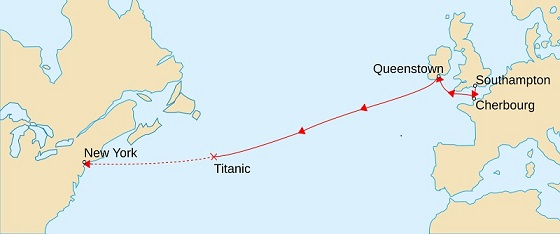  
Маршрут следующий: Southampton - Cherbourg - Qweenstown.
Если предположить, что этот признак имеет значение, то его можно кодировать как категориальный упорядоченный или неупорядоченный.  
Выберем вариант кодирования Ordinal encoding: S - 1, C - 2, Q - 3.
Для удобства работы создадим копию датафрейма data и далее будем выполнять манипуляции с ней.

In [14]:
dataset = data.copy()
dataset.loc[dataset['Sex'] == 'male', 'Sex'] = 1
dataset.loc[dataset['Sex'] == 'female', 'Sex'] = 0
dataset['Sex'] = dataset['Sex'].astype(int)
dataset.loc[dataset['Embarked'] == 'S', 'Embarked'] = 1
dataset.loc[dataset['Embarked'] == 'C', 'Embarked'] = 2
dataset.loc[dataset['Embarked'] == 'Q', 'Embarked'] = 3
dataset['Embarked'] = pd.to_numeric(dataset['Embarked'])
dataset = dataset.drop(['PassengerId'], axis = 1) # Заодно уберем столбец с идентификатором пассажира
dataset.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,1.0
1,1,1,0,38.0,1,0,71.2833,2.0
2,1,3,0,26.0,0,0,7.9250,1.0
3,1,1,0,35.0,1,0,53.1000,1.0
4,0,3,1,35.0,0,0,8.0500,1.0


**Результат действий: полностью численный датасет**

### 4. Очистка (улучшение) датасета  
Для предварительного знакомства определим основные сводные статистики и меры центральной тенденции

In [17]:
print(dataset.describe().T,'\n') # предварительный статистический анализ 

          count       mean        std   min      25%      50%   75%       max
Survived  891.0   0.383838   0.486592  0.00   0.0000   0.0000   1.0    1.0000
Pclass    891.0   2.308642   0.836071  1.00   2.0000   3.0000   3.0    3.0000
Sex       891.0   0.647587   0.477990  0.00   0.0000   1.0000   1.0    1.0000
Age       714.0  29.699118  14.526497  0.42  20.1250  28.0000  38.0   80.0000
SibSp     891.0   0.523008   1.102743  0.00   0.0000   0.0000   1.0    8.0000
Parch     891.0   0.381594   0.806057  0.00   0.0000   0.0000   0.0    6.0000
Fare      891.0  32.204208  49.693429  0.00   7.9104  14.4542  31.0  512.3292
Embarked  889.0   1.362205   0.636157  1.00   1.0000   1.0000   2.0    3.0000 



### 4.1 Работа с неопределенными значениями
Определим наличие неопределенных значений в датасете

In [19]:
dataset.isna().sum()

Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      2
dtype: int64

1. Признак Порт посадки - Embarked - имеет 2 неопределенных значения. Предлагается заменить их на 0.
2. Признак Age - возраст - имеет 177 неопределенных значений. Для принятия решения рассмотрим распределение признака и его среднее значение и медиану.

In [21]:
age_mean = dataset['Age'].mean()
age_median = dataset['Age'].median()
print(dataset['Age'].describe())
print ('age_mean = ', age_mean, 'age_median = ', age_median)

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64
age_mean =  29.69911764705882 age_median =  28.0


Среднее значение и медиана отличаются незначительно, поэтому не принципиально, каким значением будем заменять отсутствующие.
Для удобства дальнейшей работы создадим копию датасета и вносить изменения будем в нее.
Выполним замену и оценим изменение параметров распределения признака.

In [23]:
# создадим копию датасета
dataset1 = dataset.copy()
dataset1['Embarked'] = dataset1['Embarked'].fillna(0) # заменим отсутствующие значения признака "Embarked" на 0
dataset1['Age'] = dataset1['Age'].fillna(dataset1['Age'].mean()) # заменим отсутствующие значения признака "Age" на среднее значение
print(dataset1['Age'].describe())

count    891.000000
mean      29.699118
std       13.002015
min        0.420000
25%       22.000000
50%       29.699118
75%       35.000000
max       80.000000
Name: Age, dtype: float64


Создадим еще одну копию исходного датасета и вносить изменения будем в нее и удалим примеры с неопределенным значением признака "Age".  
Оценим изменение параметров распределения признака.

In [25]:
# создадим копию датасета
dataset2 = dataset.copy()
dataset2['Embarked'] = dataset2['Embarked'].fillna(0) # заменим отсутствующие значения признака "Embarked" на 0
dataset2 = dataset2[dataset2['Age'].notna()] # удалим примеры с неопределенным значением признака "Age"
print(dataset2['Age'].describe())

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64


Выполним визуализацию и сравним вид распределения по гистаграмме

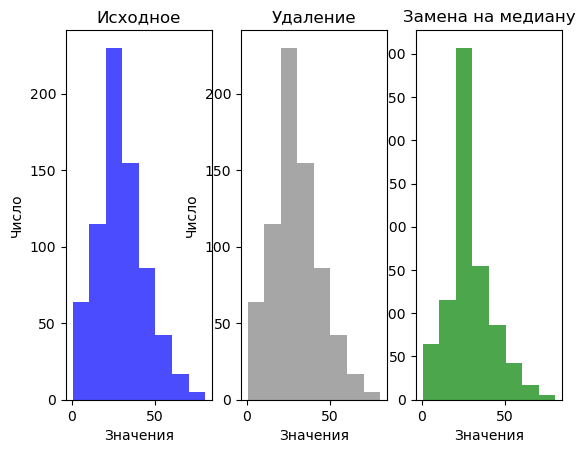

In [27]:
plt.subplot(1, 3, 1)
plt.hist(dataset['Age'], bins=8, color='blue', alpha=0.7)
plt.xlabel('Значения')
plt.ylabel('Число')
plt.title('Исходное')
plt.subplot(1, 3, 3)
plt.hist(dataset1['Age'], bins=8, color='green', alpha=0.7)
plt.xlabel('Значения')
plt.ylabel('Число')
plt.title('Замена на медиану')
plt.subplot(1, 3, 2)
plt.hist(dataset2['Age'], bins=8, color='grey', alpha=0.7)
plt.xlabel('Значения')
plt.ylabel('Число')
plt.title('Удаление')
plt.show()

**Вывод:** принимаем решение использовать датасет с удаленными неполными примерами (dataset2), т.к. он лучше соответствует исходному виду распределения.

In [29]:
# создаем копию датасета
data_clean = dataset2.copy()

### 4.2 Работа с выбросами и некорректными значениями

In [31]:
data_clean.describe().T 

,count,mean,std,min,25%,50%,75%,max
Survived,714.0,0.406162,0.491460,0.00,0.000,0.0000,1.000,1.0000
Pclass,714.0,2.236695,0.838250,1.00,1.000,2.0000,3.000,3.0000
Sex,714.0,0.634454,0.481921,0.00,0.000,1.0000,1.000,1.0000
Age,714.0,29.699118,14.526497,0.42,20.125,28.0000,38.000,80.0000
SibSp,714.0,0.512605,0.929783,0.00,0.000,0.0000,1.000,5.0000
Parch,714.0,0.431373,0.853289,0.00,0.000,0.0000,1.000,6.0000
Fare,714.0,34.694514,52.918930,0.00,8.050,15.7417,33.375,512.3292
Embarked,714.0,1.257703,0.525083,0.00,1.000,1.0000,1.000,3.0000


Анализ описания данных показал, что значения всех признаков находятся в корректных диапазонах.  
Проверим признак "Возраст" на выбросы (в качестве маркера выброса взята Z-оценка, порог 5)

In [33]:
data_clean['Age_Explosion'] = ((data_clean['Age']-data_clean['Age'].mean())/data_clean['Age'].std()>5)
print('Для признака Age по Z-оценке с параметром 5 обнаружено', data_clean['Age_Explosion'].value_counts().get(True),' выбросов')

Для признака Age по Z-оценке с параметром 5 обнаружено None  выбросов


Значимых выбросов в значении этого параметра не обнаружено.
По результатам анализа примеров с потенциальными выбросами по признаку "возраст" принято решение оставить все примеры в выборке без редактирования, т.к. они соответствуют возможным ситуациям.  

Проверим признак "Стоимость билета" на выбросы (в качестве маркера выброса взята Z-оценка, порог 5)

In [35]:
data_clean['Fare_Explosion'] = ((data_clean['Fare']-data_clean['Fare'].mean())/data_clean['Fare'].std()>5)
print('Для признака Fare по Z-оценке с параметром 5 обнаружено', data_clean['Fare_Explosion'].value_counts().get(True),' выбросов')

Для признака Fare по Z-оценке с параметром 5 обнаружено 3  выбросов


Обнаружено три примера со значимым выбросом.  
Для визуализации результатов выведем их на диаграмму рассеяния

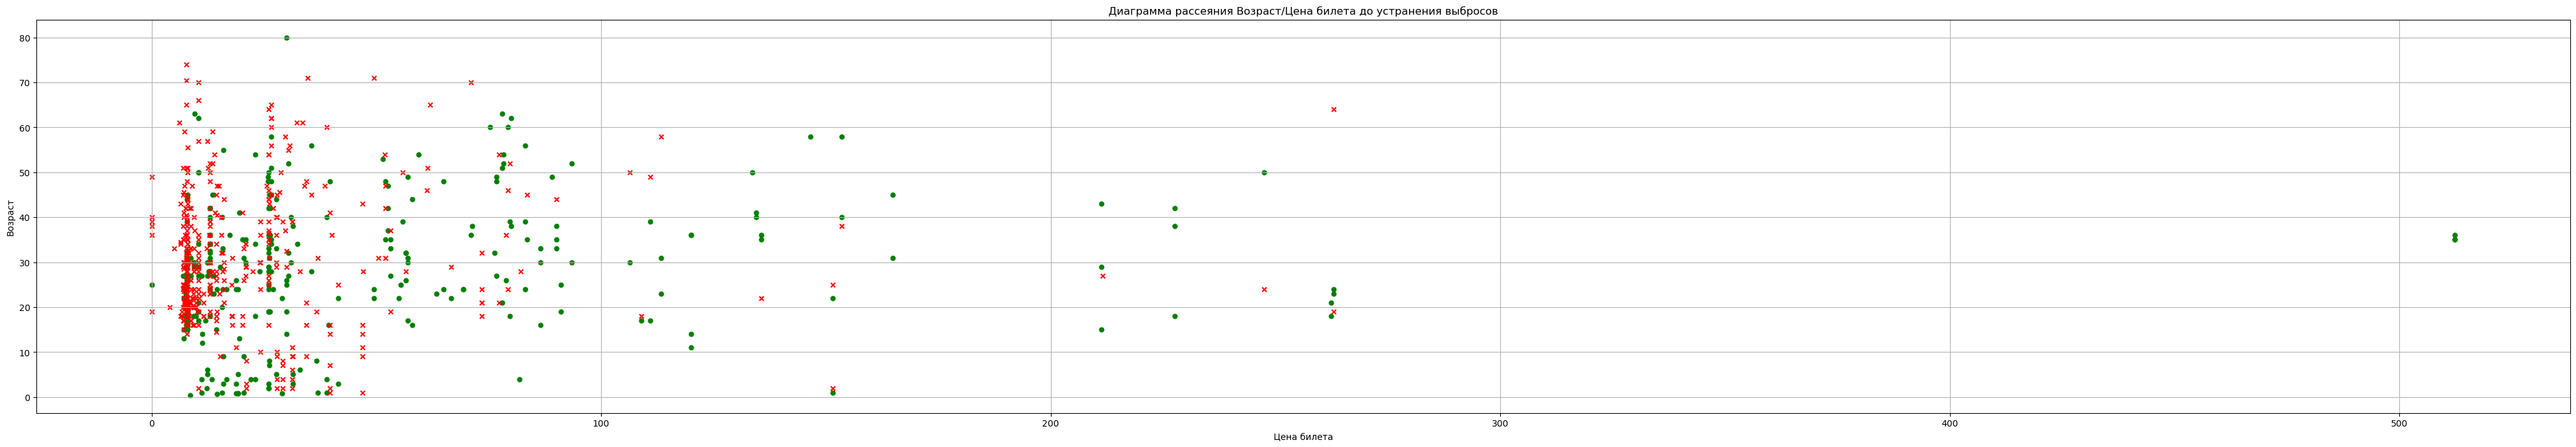

In [37]:
# для наглядного вывода разметим точки на диаграмме в зависимости от исхода катастрофы для пассажира
# Для этого разделим исходный набор данных по этому признаку на два. 
# Возможно, это не самый эффективный способ, но самый наглядный.
s=data_clean.loc[data_clean['Survived'] == 1] #выжившие
n=data_clean.loc[data_clean['Survived'] == 0] #погибшие
plt.figure(figsize=(max(data_clean['Fare'])/10, max(data_clean['Age'])/10))
plt.xlabel('Цена билета') # Подпись для оси X
plt.ylabel('Возраст') # Подпись для оси Y
plt.title('Диаграмма рассеяния Возраст/Цена билета до устранения выбросов') 
plt.grid(True) # Вывод линий сетки
plt.scatter(s['Fare'],s['Age'],marker='o', color = 'g', s = 25) # Точечная диаграмма
plt.scatter(n['Fare'],n['Age'],marker='x', color = 'r', s = 25) # Точечная диаграмма
plt.show()

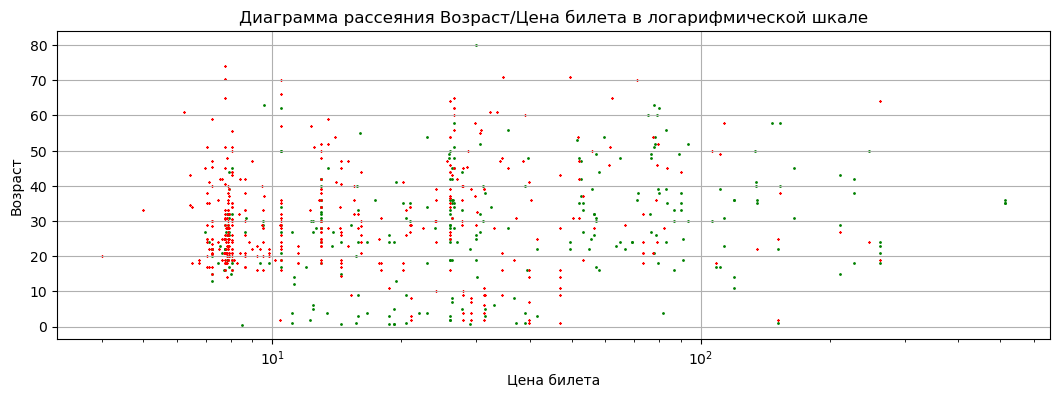

In [38]:
# Переведем диаграмму в логарифмическую шкалу
s=data_clean.loc[data_clean['Survived'] == 1] #выжившие
n=data_clean.loc[data_clean['Survived'] == 0] #погибшие
plt.figure(figsize=(max(data_clean['Fare'])/40, max(data_clean['Age'])/20))
plt.xlabel('Цена билета') # Подпись для оси X
plt.ylabel('Возраст') # Подпись для оси Y
plt.semilogx()
plt.title('Диаграмма рассеяния Возраст/Цена билета в логарифмической шкале') 
plt.grid(True) # Вывод линий сетки
plt.scatter(s['Fare'],s['Age'],marker='o', color = 'g', s = 1) # Точечная диаграмма
plt.scatter(n['Fare'],n['Age'],marker='x', color = 'r', s = 1) # Точечная диаграмма
plt.show()

По результатам анализа примеров с потенциальными выбросами по признаку "Цена билета" принято решение исключить из обучающей выборки примеры со значимым выбросом в значении этого параметра.
Для оценки результата повторно выведем диаграмму рассеяния.

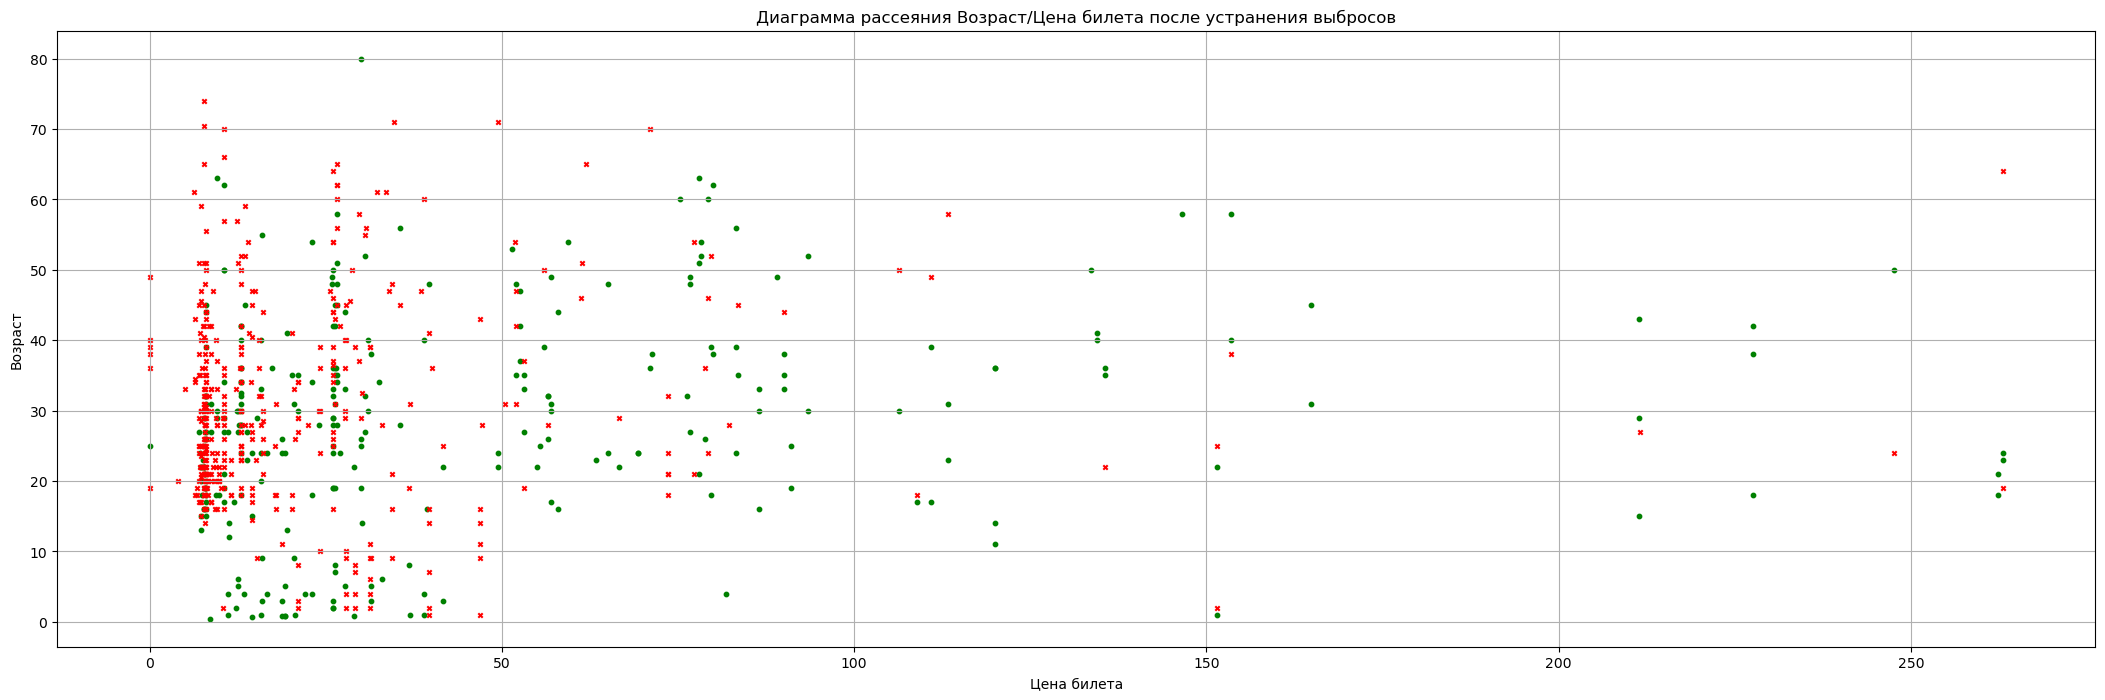

In [40]:
data_clean = data_clean.drop(data_clean[data_clean['Fare_Explosion']== True].index)
#df = df.drop(df[df['column_name'] == value].index)
s=data_clean.loc[data['Survived'] == 1] #выжившие
n=data_clean.loc[data['Survived'] == 0] #погибшие
plt.figure(figsize=(max(data_clean['Fare'])/10, max(data_clean['Age'])/10))
plt.xlabel('Цена билета') # Подпись для оси X
plt.ylabel('Возраст') # Подпись для оси Y
plt.title('Диаграмма рассеяния Возраст/Цена билета после устранения выбросов') 
plt.grid(True) # Вывод линий сетки
plt.scatter(s['Fare'],s['Age'],marker='o', color = 'g', s = 10) # Точечная диаграмма
plt.scatter(n['Fare'],n['Age'],marker='x', color = 'r', s = 10) # Точечная диаграмма
plt.show()

In [42]:
# удаление вспомогательных столбцов
data_clean = data_clean.drop('Age_Explosion', axis = 1) 
data_clean = data_clean.drop('Fare_Explosion', axis = 1)

### 5. Разведочный анализ данных
*Примечание: описание разведочного анализа дано в сокращенной форме, в работе его рекомендуется расширить*
#### 5.1. Оценка значимости параметра Sex - Пол
Для оценки значимости параметра выполним визуализацию.

In [44]:
# подготовка данных для диаграммы 1 Зависимость исхода от пола
graf = data_clean.copy()
c=len(graf.axes[0]) # всего пассажиров
s=len(graf.loc[graf['Survived'] == 1]) # из них выжившие
n=len(graf.loc[graf['Survived'] == 0]) # из них погибшие
mc=len(graf.loc[(graf['Sex']==1)]) # всего мужчин
ms=len(graf.loc[(graf['Survived'] == 1) & (graf['Sex']==1)]) #выжившие мужчины
mn=len(graf.loc[(graf['Survived'] == 0) & (graf['Sex']==1)]) #погибшие мужчины
fc=len(graf.loc[(graf['Sex']==0)])# всего женщин
fs=len(graf.loc[(graf['Survived'] == 1) & (graf['Sex']==0)]) #выжившие женщины
fn=len(graf.loc[(graf['Survived'] == 0) & (graf['Sex']==0)]) #погибшие женщины
y1=([s,ms,fs],[n,mn,fn])

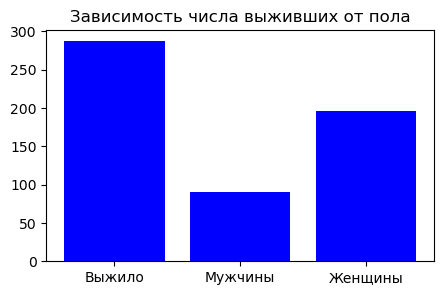

In [45]:
# Построение диаграммы
plt.figure(figsize=(5, 3))
x=['Выжило','Мужчины','Женщины']
plt.bar(x,y1[0], color = 'b') 
plt.title("Зависимость числа выживших от пола") 
plt.show() 

Диаграмма является не информативной, т.к. из нее не видно, какую долю составляли пассажиры того или иного пола в общем числе.
Учтем это при построении следующей диаграммы.

In [47]:
# подготовка данных для диаграммы 2 Зависимость исхода от пола
c=len(graf.axes[0]) # всего пассажиров
s=len(graf.loc[graf['Survived'] == 1]) # из них выжившие
n=len(graf.loc[graf['Survived'] == 0]) # из них погибшие
mc=len(graf.loc[(graf['Sex']==1)]) # всего мужчин
ms=len(graf.loc[(graf['Survived'] == 1) & (graf['Sex']==1)]) #выжившие мужчины
mn=len(graf.loc[(graf['Survived'] == 0) & (graf['Sex']==1)]) #погибшие мужчины
fc=len(graf.loc[(graf['Sex']==1)])# всего женщин
fs=len(graf.loc[(graf['Survived'] == 1) & (graf['Sex']==0)]) #выжившие женщины
fn=len(graf.loc[(graf['Survived'] == 0) & (graf['Sex']==0)]) #выжившие женщины
y=([c,mc,fc],[s,ms,fs],[n,mn,fn])

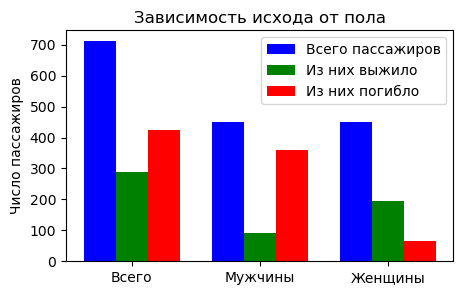

In [48]:
# Построение диаграммы
plt.figure(figsize=(5, 3))
width = 0.25
x=['Всего','Мужчины','Женщины']
ind = np.arange(len(x))

plt.bar(ind, y[0], color = 'b', width = width, label='Всего пассажиров') 
plt.bar(ind+width, y[1], color = 'g', width = width, label='Из них выжило') 
plt.bar(ind+2*width, y[2], color = 'r', width = width, label='Из них погибло') 

plt.ylabel("Число пассажиров") 
plt.title("Зависимость исхода от пола") 
plt.xticks(ind+width,x) 
plt.legend() 
plt.show() 

Диаграмма показывает, что из общего числа выживших и абсолютное, и относительное большинство составляют женщины.
Параметр является важным для классификации.

#### 5.2. Оценка значимости параметра Pclass - Класс каюты
Для оценки значимости параметра выполним визуализацию.

In [51]:
# подготовка данных для диаграммы Зависимость исхода от класса каюты
x=list(sorted(graf['Pclass'].unique()))
d=list([c,s,n])
for i in range(len(x)):
    d.append(len(graf.loc[graf['Pclass'] == x[i]])) 
    d.append(len(graf.loc[(graf['Survived'] == 1) & (graf['Pclass'] == x[i])]))
    d.append(len(graf.loc[(graf['Survived'] == 0) & (graf['Pclass'] == x[i])]))
y=np.array(d)
y=y.reshape((len(x)+1,3))
y=y.transpose()

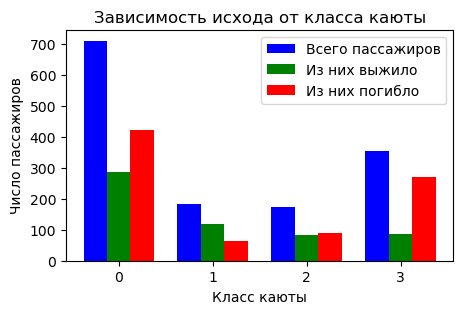

In [52]:
# Построение диаграммы
plt.figure(figsize=(5, 3))
width = 0.25
x.insert(0,0)
ind = np.arange(len(x))
plt.bar(ind, y[0], color = 'b', width = width, label='Всего пассажиров') 
plt.bar(ind+width, y[1], color = 'g', width = width, label='Из них выжило') 
plt.bar(ind+2*width, y[2], color = 'r', width = width, label='Из них погибло') 

plt.xlabel("Класс каюты") 
plt.ylabel("Число пассажиров") 
plt.title("Зависимость исхода от класса каюты") 

plt.xticks(ind+width,x) 
plt.legend() 
  
plt.show() 

Диаграмма показывает, что число выживших в относительном значении зависит от класса каюты: чем выше класс, тем больше выживших. Параметр является важным для классификации.

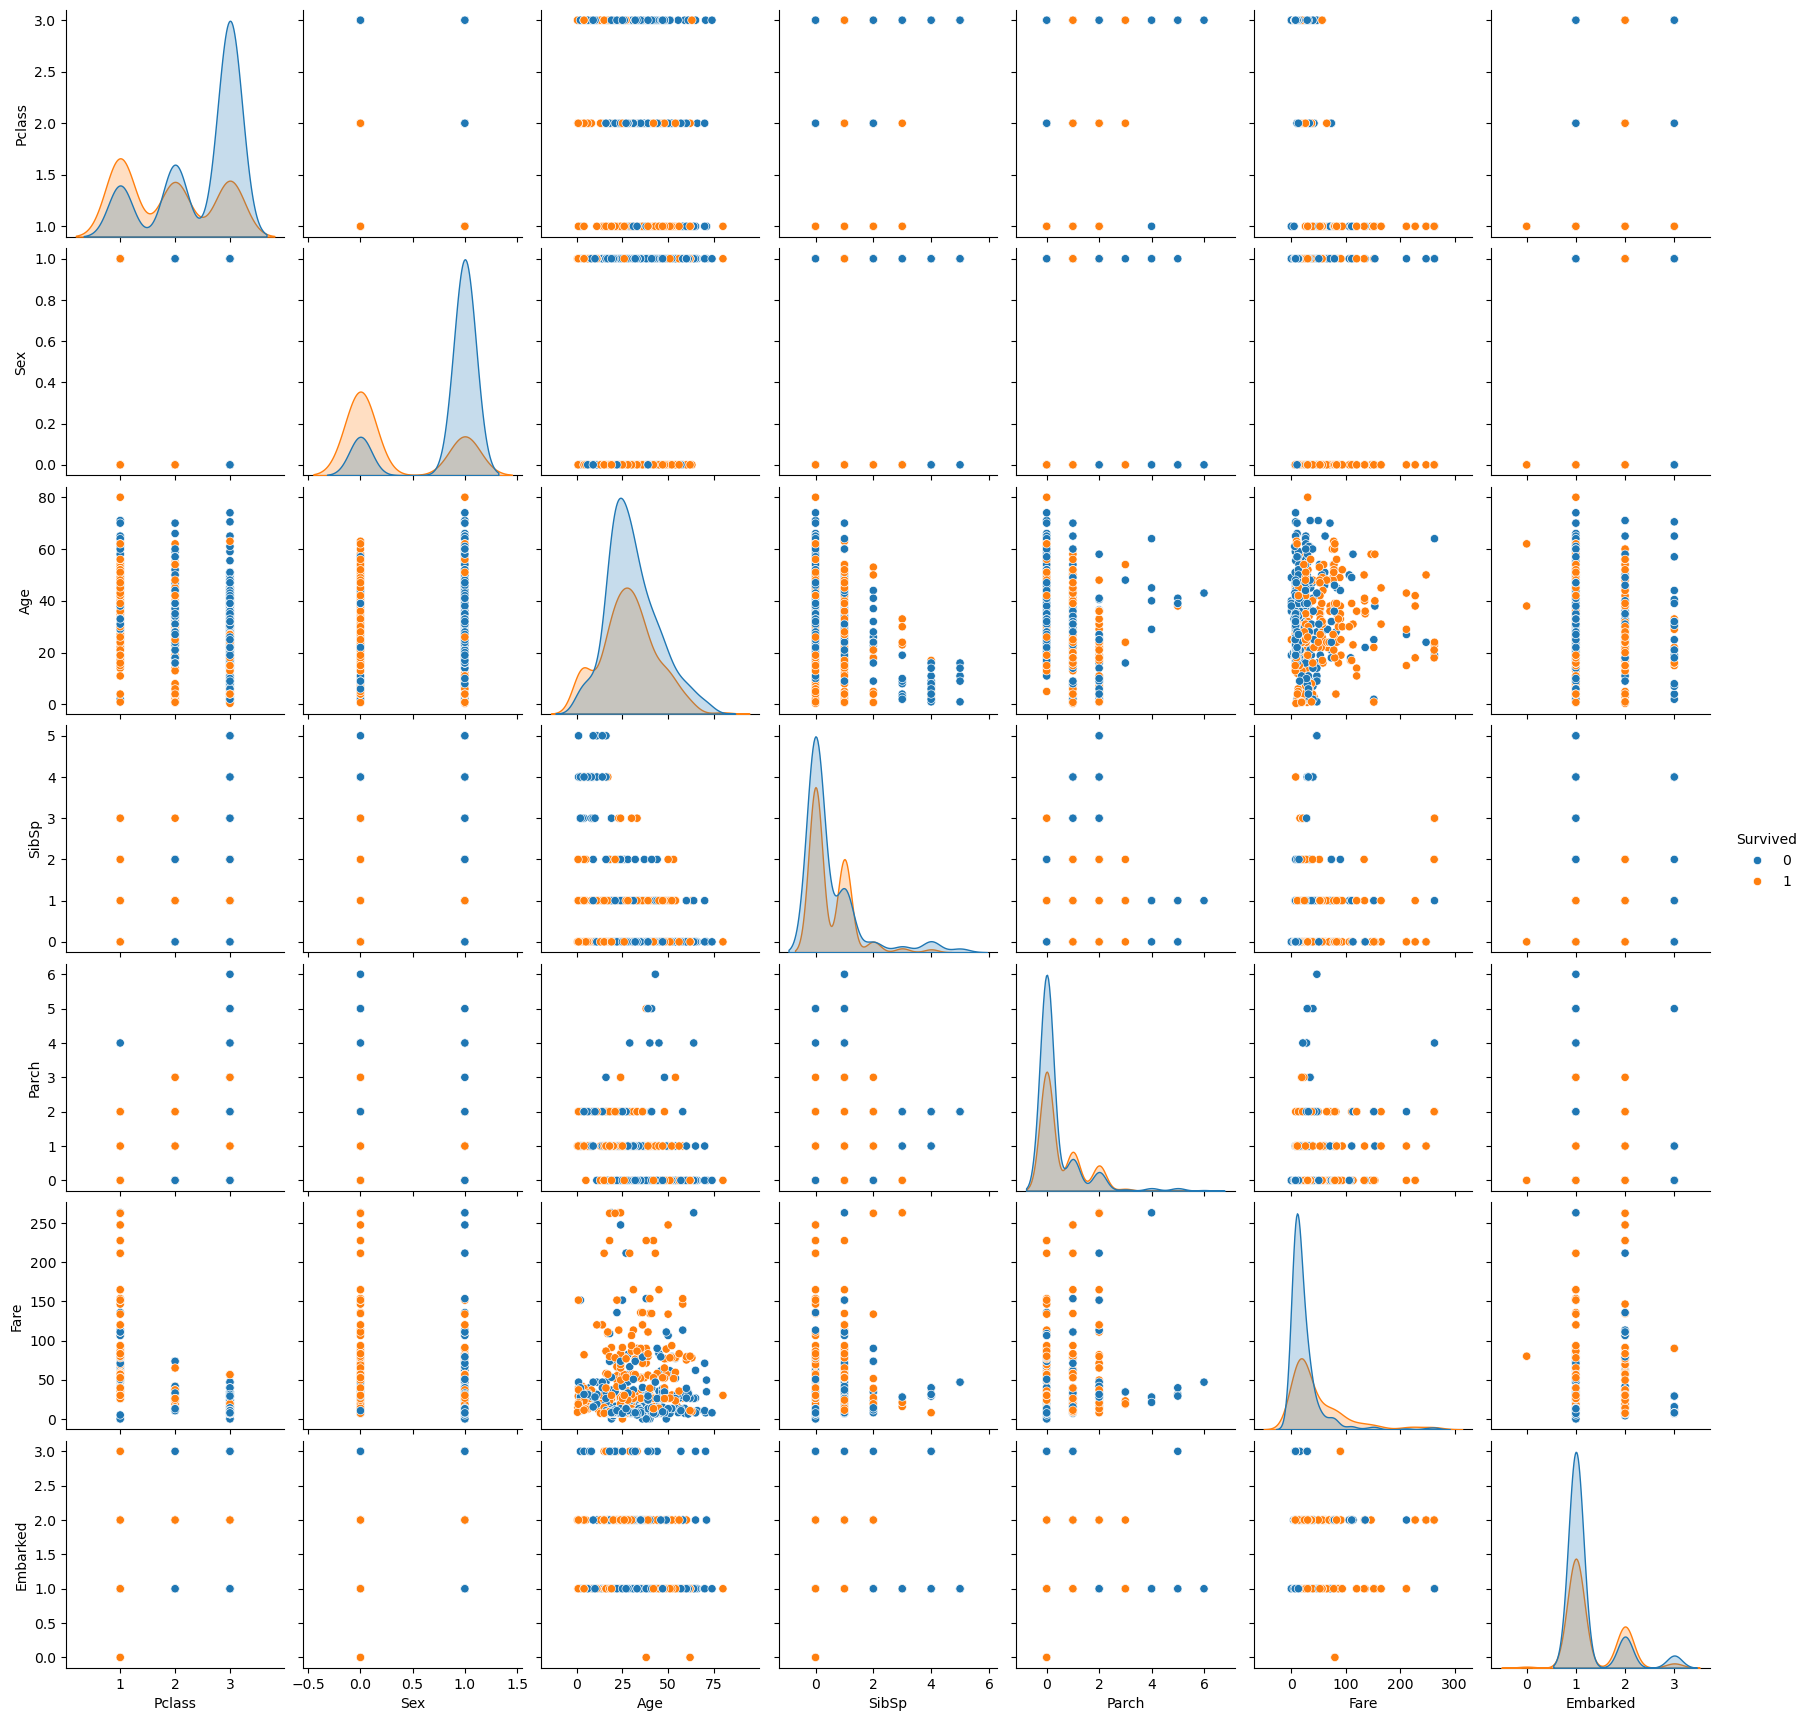

In [109]:
sns.pairplot(data = graf, hue ='Survived');

#### 5.3. Корреляционный анализ
Для определения взаимной зависимости признаков вычислим стандартный коэффициент корреляции (коэффициент Пирсона) между каждой парой признаков и визуализируем полученные результат. 
Для этого испольуется метод **.corr()**.

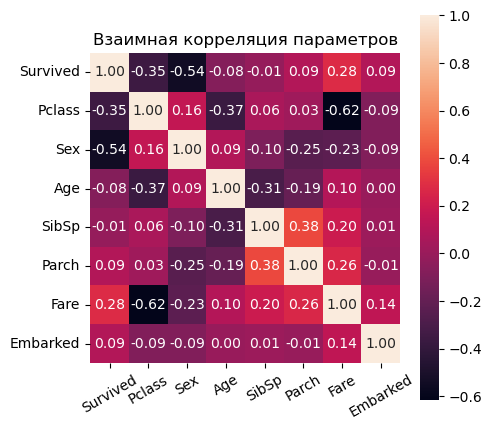

In [55]:
correlation=graf.corr()
correlation['Survived'].sort_values(ascending=False)
plt.figure(figsize=(5,5))
plt.title('Взаимная корреляция параметров')
a = sns.heatmap(correlation, square=True, annot=True, fmt='.2f', linecolor='white') # диаграмма "Тепловая карта"
a.set_xticklabels(a.get_xticklabels(), rotation=30)
a.set_yticklabels(a.get_yticklabels())           
plt.show()

Отдельно определим коэффициент корреляции (модуль) между признаками и целевым параметром.

In [57]:
correlation=abs(graf.corr())
correlation['Survived'].sort_values(ascending=False)

Survived    1.000000
Sex         0.541935
Pclass      0.354847
Fare        0.275122
Parch       0.094258
Embarked    0.092735
Age         0.079472
SibSp       0.014598
Name: Survived, dtype: float64

*Здесь должен быть анализ диаграммы на наличие взаимной корреляции признаков*  
Корреляционный анализ показал, что наименее значимым признаком является SibSp - наличие на борту супругов, братьев, сестер.
Принимаем решение исключить этот признак.

In [59]:
data_clean = data_clean.drop('SibSp', axis = 1) # удаляем признак "SibSp"
data_clean

,Survived,Pclass,Sex,Age,Parch,Fare,Embarked
0,0,3,1,22.0,0,7.2500,1.0
1,1,1,0,38.0,0,71.2833,2.0
2,1,3,0,26.0,0,7.9250,1.0
3,1,1,0,35.0,0,53.1000,1.0
4,0,3,1,35.0,0,8.0500,1.0
...,...,...,...,...,...,...,...
885,0,3,0,39.0,5,29.1250,3.0
886,0,2,1,27.0,0,13.0000,1.0
887,1,1,0,19.0,0,30.0000,1.0
889,1,1,1,26.0,0,30.0000,2.0


#### 6. Масштабирование параметров

В обучающей выборке два числовых параметра с существенно различающимся интервалом значений: возраст 'Age' и стоимость билета 'Fare'.
Предлагается провести мин-макс нормализацию значений этих параметров.

In [62]:
train=data_clean.copy()
labels=['Age', 'Fare']
for l in labels:
    train[l]=(train[l]-train[l].min())/train[l].max()
train.head()

,Survived,Pclass,Sex,Age,Parch,Fare,Embarked
0,0,3,1,0.26975,0,0.027567,1.0
1,1,1,0,0.46975,0,0.271039,2.0
2,1,3,0,0.31975,0,0.030133,1.0
3,1,1,0,0.43225,0,0.201901,1.0
4,0,3,1,0.43225,0,0.030608,1.0


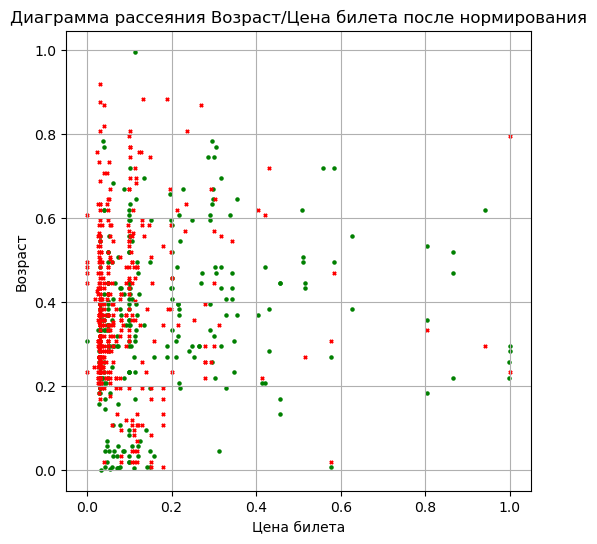

In [63]:
s=train.loc[data['Survived'] == 1] #выжившие
n=train.loc[data['Survived'] == 0] #погибшие

plt.figure(figsize=(max(train['Fare']*6), max(train['Age'])*6))
plt.xlabel('Цена билета') # Подпись для оси X
plt.ylabel('Возраст') # Подпись для оси Y
plt.title('Диаграмма рассеяния Возраст/Цена билета после нормирования') 
plt.grid(True) # Вывод линий сетки
plt.scatter(s['Fare'],s['Age'],marker='o', color = 'g', s = 5) # Точечная диаграмма
plt.scatter(n['Fare'],n['Age'],marker='x', color = 'r', s = 5) # Точечная диаграмма
plt.show()

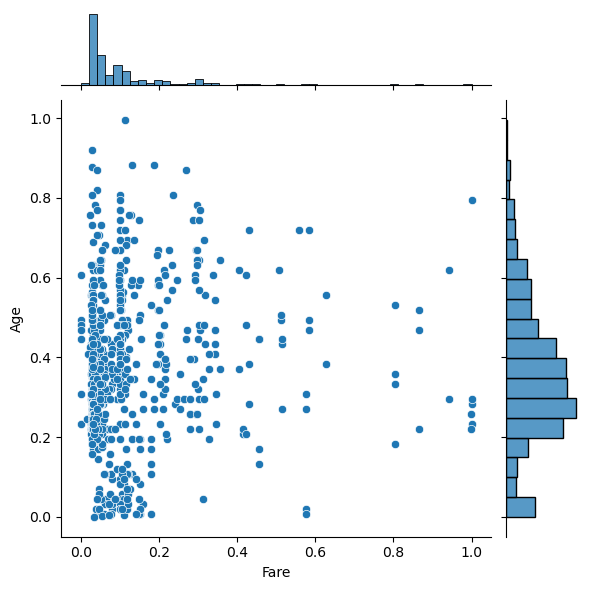

In [101]:
sns.jointplot(x="Fare", y="Age", data=train, kind="scatter");

#### 7. Формирование и сохранение тестовой и обучающей выборок

In [65]:
train.loc[0:750].to_csv("train1.csv", index=False) 
train.loc[751:890].to_csv("test1.csv", index=False) 